#### Q3

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import time

#####  uniform reconstruction

In [ ]:
def step_func (Vec_len):
    x = np.linspace(0, 1, Vec_len)  
    y = np.abs(np.where(np.sign(np.cos(2 * np.pi / 1 * x)) > 0, 1, 0)-1) # fliiping sides
    return y

def goust_func(a):
    a[0] = a[-1]; # a_0 = a_N-1
    a = np.append(a,a[1]) # a_N = a_1
    a = np.append(a[-3],a) # a_-1 = a_N-2
    return a
    
def upwind_t(a,C):
    a = goust_func(a)
    ai = a[1:]; aii = a[0:-1]
    return ai - C*(ai-aii)


def upwind_x(a,dx):
    a_ = a[1:]
    a_[0] = a_[-1]
    return a_

def eps_func(a_end,a0,N):
    dx = 1/N
    return dx * sum((a_end-a0)**2)

def upwind_advection(C=0.5, N=64, u=1,plot_init=True,plot_mid=True,plot_end=True):
    dx = 1/N; T = 1/u; dt = C/u * dx
    step = []
    step.append(step_func(N))
    t_vec = np.linspace(0,T,round(1/dt)+1)
    x_vec = np.linspace(0,1,N)
    for tt in range(len(t_vec)):
        
        step_t = upwind_t(step[-1],C)
        step_tx = upwind_x(step_t,dx)
        step.append(step_tx)
        
        if tt%50 == 0 and plot_mid == True:   
            plt.plot(x_vec,step[-1]); plt. title (f't/T = %{t_vec[tt]/T*100:.2f}'); plt.show() 
    if plot_end == True:
        if plot_init == True:
            plt.plot(x_vec,step[0]); plt. title (f'N = {N} t/T = %{t_vec[tt]/T*100:.2f}')
        
        plt.plot(x_vec,step[-1]); plt. title (f'N = {N} t/T = %{t_vec[tt]/T*100:.2f}'); plt.show() 
        plt.show()

    return step


    print("The time stpes dt the sysem is for CLF is between 0 to 1, so the maximal dt is then dx/u where dx=1/N is the grid step")
if upwind_advection:
    upwind_advection()
        

    

##### Linear piecewise reconstruction

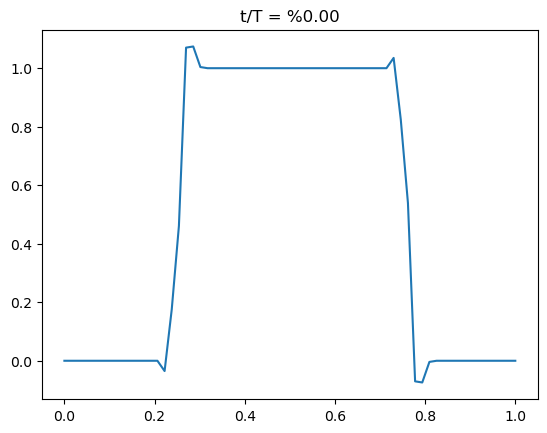

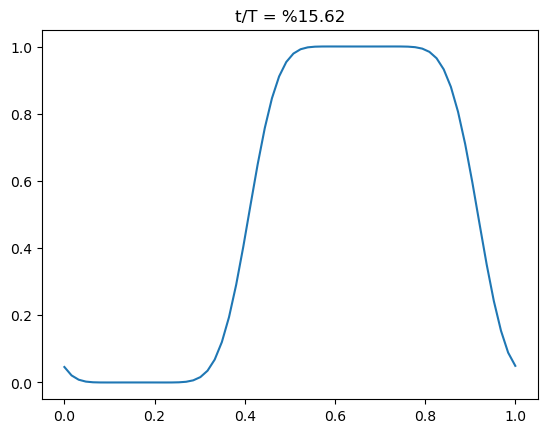

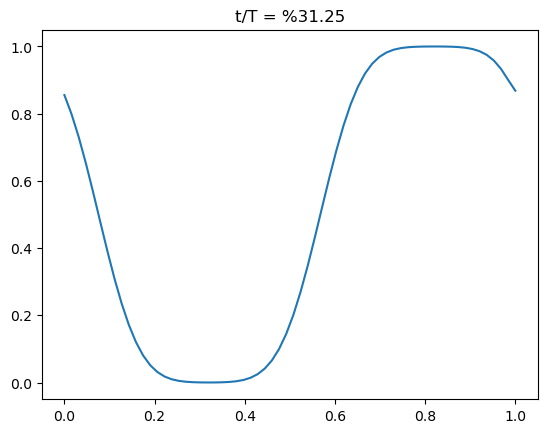

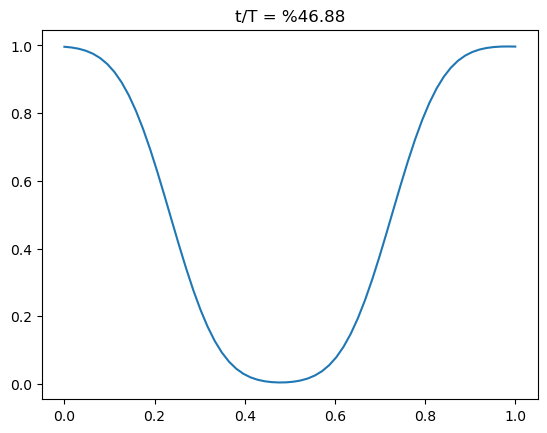

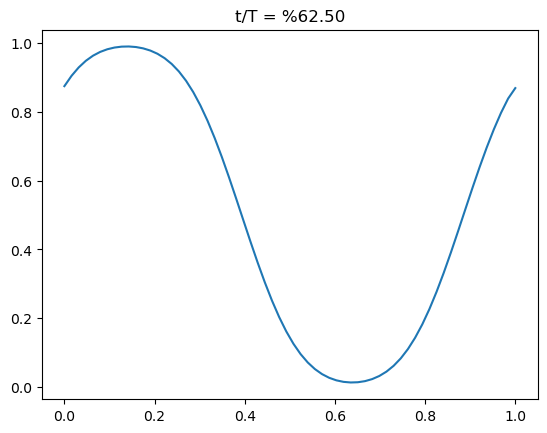

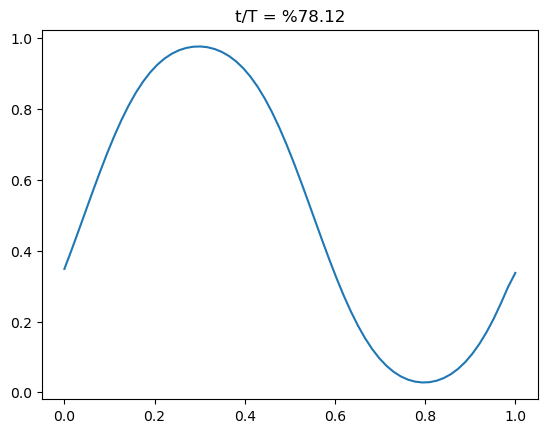

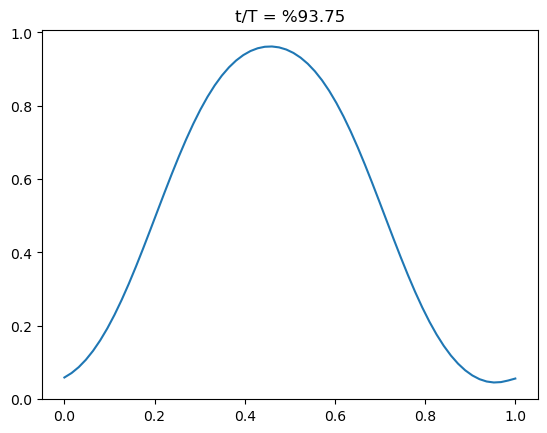

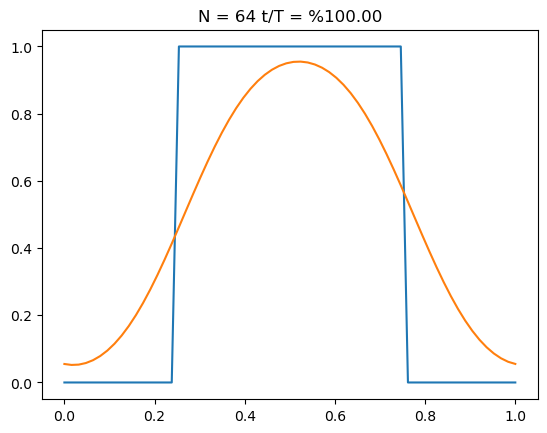

In [42]:
def step_func (Vec_len):
    x = np.linspace(0, 1, Vec_len)  
    y = np.abs(np.where(np.sign(np.cos(2 * np.pi / 1 * x)) > 0, 1, 0)-1) # fliiping sides
    return y

def goust_func(a):
    a_ = np.zeros(len(a)+4)
    a_[2:-2] = np.copy(a)
    a_[-1 -1] = a[0]; #  a_N-1 = a_0
    a_[-1] = a[1] # a_N = a1
    # a_[-1] = a[2]
    a_[0] = a[-1 -2]  # a_-1 = a_N-2
    a_[1] = a[-1 -1]
    return a_

def lax_func (a,C):
    a_ = goust_func(a)
    aip1 = a_[2:-2]; aim1 = a_[0:-4]
    a_new = a + C/2*(aip1-aim1)+ (C**2)/2 * (aip1+aim1-2*a)
    return a_new
    
    
def a_half_x_func(a,dx,u):
    Da = (a[2:]-a[:-2]) /(2*dx)   # (a_{i+1} - a_{i-1}) /2   
    if u>0:
        a_ = a[1:-1] + dx*Da/2 # upwind from left to right  a
    else:
        a_ = a[1:-1] - dx*Da/2 # upwind from right to left
    return a_


def a_half_t_func (a,a_half,dt,u):
    return a + dt/2*1



def upwind_t(a,C,dx,dt,u):
    a_ = goust_func(a)
    
    Da = (a_[2:]-a_[:-2]) /(2*dx)
    if u>0:
        a_half_x = a_[1:-1] + dx*Da/2 # upwind from left to right  a
        F_1_2 = u*a_half_x
        k1 = -1/dx * (F_1_2[1:]-F_1_2[:-1])
        a_half_t = a_[1:-2] + dt/2*k1
        F_12_12 = u*(a_half_t)
        k2 = -1/dx * (F_12_12[1:] - F_12_12[:-1])
        a_new = a + dt *k2
    else:
        a_half_x = a_[1:-1] - dx*Da/2 # upwind from right to left
        F_1_2 = u*a_half_x
        k1 = -1/dx * (F_1_2[:-1]-F_1_2[1:])
#         print(len(a_[0:-3]))
        a_half_t = a_[1:-2] + dt/2*k1
        F_12_12 = u*(a_half_t)
        k2 = -1/dx * (F_12_12[0:-1] - F_12_12[1:])
#     print(len(k2))
        a_new = a + dt *k2
#     print(len(a_new))
    
#     a_half_x = a_half_x_func(a_,dx,u)
# #     print(len(a_half_x))
#     F_1_2 = u*a_half_x
#     print(len(F_1_2[1:]))
#     k1 = -1/dx*(F_1_2[1:]-F_1_2[:-1])
#     F_12_12 = u*(a+dt/2*k1)
#     K2 = -1/dx * (F_12_12[1:] - F_12_12[:-1])
#     a_new = a +1/dt *K2
#     # a_half_t = a_half_t_func(a_,a_half_x,dx,dt,u)
#     # a_ = a - C*(a_half_x[1:-1] - a_half_x[:-2])
    # print(len(a_new))
    return a_new








# def upwind_t(a,C,dx,dt,u):
#     a_ = goust_func(a)
#     a_half_x = a_half_x_func(a_,dx,u)
# #     print(len(a_half_x))
#     F_1_2 = u*a_half_x
#     print(len(F_1_2[1:]))
#     k1 = -1/dx*(F_1_2[1:]-F_1_2[:-1])
#     F_12_12 = u*(a+dt/2*k1)
#     K2 = -1/dx * (F_12_12[1:] - F_12_12[:-1])
#     a_new = a +1/dt *K2
#     # a_half_t = a_half_t_func(a_,a_half_x,dx,dt,u)
#     # a_ = a - C*(a_half_x[1:-1] - a_half_x[:-2])
#     # print(len(a_new))
#     return a_new

    
def upwind_x(a,dx):
    a_ = a[1:]
    a_ = np.append(a[-1],a_)
    return a_

def eps_func(a_end,a0,N):
    dx = 1/N
    return dx * sum((a_end-a0)**2)


def linear_reconstract_func(C=0.5, N=2**6, u=-1,plot_init=True,plot_mid=True,plot_end=True):
    dx = 1/N; T = 1/np.abs(u); dt = C/np.abs(u) * dx
    step = []
    stepm2 = np.zeros(N)
    # print(stepm2[0])
    # step.append(stepm2)
    step.append(step_func(N))
    # step.append(step_func(N))
    step.append(lax_func(step[-1],C))
    # print(step[-1])
    t_vec = np.linspace(0,T,round(1/dt)+1)
    x_vec = np.linspace(0,1,N)
    
    for tt in range(len(t_vec)):
        step_t = upwind_t(step[-1],C,dx,dt,u)
        step_tx = upwind_x(step_t,dx)
        # print(len(step_tx))
        step.append(step_t)
        if tt%20 == 0 and plot_mid == True:   
            plt.plot(x_vec,step[-1]); plt. title (f't/T = %{t_vec[tt]/T*100:.2f}'); plt.show() 
    if plot_end == True:
        if plot_init == True:
            plt.plot(x_vec,step[0]); plt. title (f'N = {N} t/T = %{t_vec[tt]/T*100:.2f}')
        
        plt.plot(x_vec,step[-1]); plt. title (f'N = {N} t/T = %{t_vec[tt]/T*100:.2f}'); plt.show() 
        plt.show()
    return step
        
if linear_reconstract_func:
    linear_reconstract_func()

NameError: name 'step' is not defined

In [68]:
# def ghost(a):
a = np.array([1,2,3,4,5,6,7,8,9,10])
g = np.zeros(len(a) + 4)
g[2:-2] = a          # real cells

    # periodic BCs
g[0]  = a[-2]        # i = -2  ← N-2
g[1]  = a[-1]        # i = -1  ← N-1
g[-2] = a[0]         # i = N   ← 0
g[-1] = a[1]         # i = N+1 ← 1
print( g)

[ 9. 10.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10.  1.  2.]


In [69]:
import numpy as np

def apply_periodic_ghost_cells_order2(a_inner):
    """
    Applies periodic boundary conditions requiring 2 ghost cells on each side 
    (P=2) for a higher-order numerical scheme.

    Periodic Conditions:
    - Left Ghost Cells (a_{-1}, a_0) = Rightmost Physical Cells (a_{N-1}, a_N)
    - Right Ghost Cells (a_{N+1}, a_{N+2}) = Leftmost Physical Cells (a_1, a_2)

    Args:
        a_inner (np.ndarray): A 1D NumPy array representing the physical domain 
                              (a_1 to a_N).

    Returns:
        np.ndarray: A new 1D array including the two ghost cells on the left 
                    and two on the right.
    """
    
    # 1. Identify the values needed for the ghost cells (P=2)
    
    # The two left ghost cells come from the two points at the end of the array:
    # [a_{-1}, a_0] = [a_{N-1}, a_N]
    left_ghost_values = a_inner[-2:]
    
    # The two right ghost cells come from the two points at the start of the array:
    # [a_{N+1}, a_{N+2}] = [a_1, a_2]
    right_ghost_values = a_inner[:2]
    
    # 2. Concatenate the ghost cells with the inner array
    # Structure: [a_{-1}, a_0, a_1, ..., a_N, a_{N+1}, a_{N+2}]
    a_full = np.concatenate((left_ghost_values, a_inner, right_ghost_values))
    
    return a_full

# --- Example Usage ---
# Physical domain with 6 points: a_1=10, a_2=20, a_3=30, a_4=40, a_5=50, a_6=60
a_inner_values = np.array([10, 20, 30, 40, 50, 60])
N = len(a_inner_values) # N = 6

print(f"**Original Inner Array (a_1 to a_N):**")
print(f"a_inner: {a_inner_values}")
print(f"Length N: {N}")
print("-" * 50)

# Apply the periodic boundary conditions with 2 ghost cells
a_full_domain = apply_periodic_ghost_cells_order2(a_inner_values)

# Output the result
print(f"**Array with 2 Periodic Ghost Cells per side (Length N+4):**")
print(f"a_full: {a_full_domain}")
print(f"Length: {len(a_full_domain)}")
print("-" * 50)

# Verification
print("Verification of Ghost Cell Assignment:")
# Left Ghost Cells: [a_{-1}, a_0]
print(f"Left Ghost Cells (Indices 0, 1): {a_full_domain[0:2]} (Should be a_{N-1}, a_N: 50, 60)")
# Right Ghost Cells: [a_{N+1}, a_{N+2}]
print(f"Right Ghost Cells (Indices N+2, N+3): {a_full_domain[-2:]} (Should be a_1, a_2: 10, 20)")

**Original Inner Array (a_1 to a_N):**
a_inner: [10 20 30 40 50 60]
Length N: 6
--------------------------------------------------
**Array with 2 Periodic Ghost Cells per side (Length N+4):**
a_full: [50 60 10 20 30 40 50 60 10 20]
Length: 10
--------------------------------------------------
Verification of Ghost Cell Assignment:
Left Ghost Cells (Indices 0, 1): [50 60] (Should be a_5, a_N: 50, 60)
Right Ghost Cells (Indices N+2, N+3): [10 20] (Should be a_1, a_2: 10, 20)


In [ ]:
def step_func (Vec_len):
    x = np.linspace(0, 1, Vec_len)  
    y = np.abs(np.where(np.sign(np.cos(2 * np.pi / 1 * x)) > 0, 1, 0)-1) # fliiping sides
    return y

def goust_func(a):

# # print(a)
    # a[0] = a[-1]; # a_0 = a_N-1
    # a = np.append(a,a[1]) # a_N = a_1
    # a = np.append(a,a[2])
    # a = np.append(a[-4],a) # a_-1 = a_N-2
    # a = np.append(a[-5],a) # a_-2 = a_N-3
    # return a
    g = np.zeros(len(a) + 4)
    g[2:-2] = a
    g[0]  = a[-2]#-2        # a_-2-a_N-2   
    g[1]  = a[-1]#-1        # a_-1=a_N-1
    g[-2] = a[1]         # a_N+1 = N
    g[-1] = a[2]         # a_N+2 = a_1
    return g
    
def a_half_func(a,dx,u):
        # Da = (a[2:]-a[:-2]) /(2*dx)   # (a_{i+1} - a_{i-1}) /2   
        Da = (a[3:-1] - a[1:-3]) / (2.0 * dx)
    
        if u>0:
            a_ = a[2:-2] + dx*Da/2 # upwind from left to right  a
        else:
            a_ = a[2:-2] - dX*Da/2 # upwind from right to left
        # print (len(a[1:-1]))  
        return a_


def upwind_t(a,C,dx,u):
    a_ = goust_func(a)
    a_p_half = a_half_func(a_,dx,u)
    a_m_half = np.copy(a_p_half)
    a_m_half[1:] = a_p_half[:-1]
    a_m_half[0] = a_p_half[-1]
    
    # a_ = a_[2:-2] - C*(a_half[2:] - a_half[:-2] )
    # a_ = a_[2:-2] - C*(a_half[1:-1] - a_half[0:-2] )
    # a_ = a_ - C*(a_half[1:-1] - a_half[0:-2] )
    # a_ = a_[2:-2] - C*(a_half[2-1:-1] - a_half[1-1:-2])
    # print(a_half[2:] - a_half[:-2])
    # print(a_half[2-1:-1] - a_half[1-1:-2])
    # print(len(a_half))
    # print(a_half[2:] - a_half[:-2])

    
    return a - C*(a_p_half-a_m_half)

    
def upwind_x(a,dx):
    # a_ip1 = a[2:]
    # a_im1 = a[:-2]
    # a_ = a[1:-1]
    
    a_ = a[1:]
    a_ = np.append(a[-1],a_)
    # print(len(a_))
    
    # print(len(a_))
    # a_ = (a_ip1 - a_im1)
    # a_[0] = a_[-1]
    # print(len(a_))
    return a_

def eps_func(a_end,a0,N):
    dx = 1/N
    return dx * sum((a_end-a0)**2)




def linear_reconstract_func(C=0.1, N=2**6, u=1,plot_init=True,plot_mid=False,plot_end=True):
    dx = 1/N; T = 1/np.abs(u); dt = C/np.abs(u) * dx
    step = []
    stepm2 = np.zeros(N)
    # print(stepm2[0])
    # step.append(stepm2)
    step.append(step_func(N))
    step.append(step_func(N))
    # print(step[-1])
    t_vec = np.linspace(0,T,round(1/dt)+1)
    x_vec = np.linspace(0,1,N)
    
    for tt in range(len(t_vec)):
        step_t = upwind_t(step[-1],C,dx,u)
        step_tx = upwind_x(step_t,dx)
        # print(len(step_tx))
        step.append(step_t)
        if tt%50 == 0 and plot_mid == True:   
            plt.plot(x_vec,step[-1]); plt. title (f't/T = %{t_vec[tt]/T*100:.2f}'); plt.show() 
    if plot_end == True:
        if plot_init == True:
            plt.plot(x_vec,step[1]); plt. title (f'N = {N} t/T = %{t_vec[tt]/T*100:.2f}')
        
        plt.plot(x_vec,step[-1]); plt. title (f'N = {N} t/T = %{t_vec[tt]/T*100:.2f}'); plt.show() 
        plt.show()

    return step
        
if linear_reconstract_func:
    linear_reconstract_func()


In [3]:
qqq = np.array([0,1,2,3,4,5])
print(qqq[0:-1])

[0 1 2 3 4]


In [ ]:
def step_func (Vec_len):
    x = np.linspace(0, 1, Vec_len)  
    y = np.abs(np.where(np.sign(np.cos(2 * np.pi / 1 * x)) > 0, 1, 0)-1) # fliiping sides
    return y

def goust_func(a):
    a_ = np.zeros(len(a)+4)
    a_[2:-2] = np.copy(a)
    a_[-1 -2] = a[0]; #  a_N-1 = a_0
    a_[-2] = a[1] # a_N = a1
    a_[-1] = a[2]
    a_[0] = a[-1 -2]  # a_-1 = a_N-2
    a_[1] = a[-1 -1]
    return a_

def lax_func (a,C):
    a_ = goust_func(a)
    aip1 = a_[2:-2]; aim1 = a_[0:-4]
    
    a_new = a + C/2*(aip1-aim1)+ (C**2)/2 * (aip1+aim1-2*a)
    
    # print(len(a_new))
    return a_new
    
    
def a_half_x_func(a,dx,u):
    
    Da = (a[2:]-a[:-2]) /(2*dx)   # (a_{i+1} - a_{i-1}) /2   
    # print(len(Da))
    if u>0:
        a_ = a[1:-1] + dx*Da/2 # upwind from left to right  a
        
    else:
        # print(dx)
        a_ = a[1:-1] - dx*Da/2 # upwind from right to left
        # print (len(a_))  
    return a_


def a_half_t_func (a,dt,u):
    k1 = -1/dx *1
    return a + dt/2*1


def upwind_t(a,C,dx,u):
    a_ = goust_func(a)
    
    a_half_x = a_half_x_func(a_,dx,u)
    # a_half_t = a_half_t_func (a_,a_half_x,dt)
    # print(len(a_half))
    # a_ = a_[2:-2] - C*(a_half[2:] - a_half[:-2] )
    a_ = a - C*(a_half_x[1:-1] - a_half_x[:-2])
    # a_ = a_ - C*(a_half[1:-1] - a_half[0:-2] )
    # a_ = a_[2:-2] - C*(a_half[2-1:-1] - a_half[1-1:-2])
    # print(a_half[2:] - a_half[:-2])
    # print(a_half[2-1:-1] - a_half[1-1:-2])
    # print(len(a_half))
    # print(a_half[2:] - a_half[:-2])
    # print(len(a_))
    return a_

    
def upwind_x(a,dx):
    # a_ip1 = a[2:]
    # a_im1 = a[:-2]
    # a_ = a[1:-1]
    
    a_ = a[1:]
    a_ = np.append(a[-1],a_)
    # print(len(a_))
    
    # print(len(a_))
    # a_ = (a_ip1 - a_im1)
    # a_[0] = a_[-1]
    # print(len(a_))
    return a_

def eps_func(a_end,a0,N):
    dx = 1/N
    return dx * sum((a_end-a0)**2)




def linear_reconstract_func(C=0.1, N=2**6, u=1,plot_init=True,plot_mid=False,plot_end=True):
    dx = 1/N; T = 1/np.abs(u); dt = C/np.abs(u) * dx
    step = []
    stepm2 = np.zeros(N)
    # print(stepm2[0])
    # step.append(stepm2)
    step.append(step_func(N))
    # step.append(step_func(N))
    step.append(lax_func(step[-1],C))
    # print(step[-1])
    t_vec = np.linspace(0,T,round(1/dt)+1)
    x_vec = np.linspace(0,1,N)
    
    for tt in range(len(t_vec)):
        step_t = upwind_t(step[-1],C,dx,u)
        step_tx = upwind_x(step_t,dx)
        # print(len(step_tx))
        step.append(step_t)
        if tt%50 == 0 and plot_mid == True:   
            plt.plot(x_vec,step[-1]); plt. title (f't/T = %{t_vec[tt]/T*100:.2f}'); plt.show() 
    if plot_end == True:
        if plot_init == True:
            plt.plot(x_vec,step[0]); plt. title (f'N = {N} t/T = %{t_vec[tt]/T*100:.2f}')
        
        plt.plot(x_vec,step[-1]); plt. title (f'N = {N} t/T = %{t_vec[tt]/T*100:.2f}'); plt.show() 
        plt.show()

    return step
        
if linear_reconstract_func:
    linear_reconstract_func()